In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, time, date, timedelta
from zoneinfo import ZoneInfo  # для Python 3.9+ (вместо pytz)
import requests
import openmeteo_requests
import requests_cache
from retry_requests import retry
from astral import LocationInfo
from astral.sun import sun
from astral.geocoder import database, lookup
import holidays

# Для обратной совместимости можно использовать pytz, но ZoneInfo встроен в Python 3.9+
# Если у вас Python < 3.9, установите pytz и используйте from pytz import timezone

# Настройка клиента Open-Meteo с кэшированием и повторами запросов
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

In [ ]:
df=pd.read_csv('output/fact_dtp.csv')

C:\Users\user\AppData\Local\Temp\ipykernel_17024\520310257.py:1: DtypeWarning: Columns (0: scheme_code, 1: road_loc) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('output/fact_dtp.csv')


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41131 entries, 0 to 41130
Data columns (total 47 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   dtp_id                           41131 non-null  int64  
 1   moment_date                      41131 non-null  str    
 2   moment_time                      41131 non-null  str    
 3   type_code                        41131 non-null  int64  
 4   type_name                        41131 non-null  str    
 5   vehicles_count                   41131 non-null  int64  
 6   dead_count                       41131 non-null  int64  
 7   dead_children_count              41131 non-null  int64  
 8   injured_count                    41131 non-null  int64  
 9   injured_children_count           41131 non-null  int64  
 10  scheme_code                      16570 non-null  str    
 11  place_latitude                   41131 non-null  float64
 12  place_longitude              

In [ ]:

# Приводим типы данных
df['moment_date'] = pd.to_datetime(df['moment_date'])

df['datetime'] = pd.to_datetime(df['moment_date'].astype(str) + ' ' + df['moment_time'])
# Удаляем tz, если вдруг он появился (на случай, если данные были с tz)
df['datetime'] = df['datetime'].dt.tz_localize(None)
# ========== ФИЛЬТР: оставляем только 2022, 2023, 2024 ==========
df = df[df['moment_date'].dt.year.isin([2022, 2023, 2024])].reset_index(drop=True)
print(f"После фильтрации по годам 2022-2024: {len(df)} строк")


In [ ]:
def get_weather_data(lat, lon, start_date, end_date):
    """Возвращает DataFrame с почасовой погодой. Дата/время — naive (без tz), в московском времени."""
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d"),
        "hourly": ["temperature_2m", "apparent_temperature", "precipitation", "rain", "snowfall",
                   "snow_depth", "wind_speed_10m", "wind_gusts_10m", "relative_humidity_2m",
                   "surface_pressure", "visibility"],
        "timezone": "Europe/Moscow"
    }
    try:
        responses = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)
        response = responses[0]
        hourly = response.Hourly()
        
        # Получаем временные метки в UTC, затем переводим в Europe/Moscow и удаляем tz (делаем naive)
        start_utc = pd.to_datetime(hourly.Time(), unit="s", utc=True)
        start_msk = start_utc.tz_convert("Europe/Moscow")
        start_naive = start_msk.tz_localize(None)
        
        # Создаём диапазон с тем же интервалом
        hourly_data = {
            "date": pd.date_range(
                start=start_naive,
                periods=hourly.Variables(0).ValuesAsNumpy().shape[0],
                freq=pd.Timedelta(seconds=hourly.Interval()),
                inclusive="left"
            )
        }
        variables = ["temperature_2m", "apparent_temperature", "precipitation", "rain", "snowfall",
                     "snow_depth", "wind_speed_10m", "wind_gusts_10m", "relative_humidity_2m",
                     "surface_pressure", "visibility"]
        for i, var in enumerate(variables):
            hourly_data[var] = hourly.Variables(i).ValuesAsNumpy()
        
        return pd.DataFrame(data=hourly_data)
    except Exception as e:
        err_str = str(e)
        print(f"Ошибка погоды для {lat},{lon}: {e}")
        if 'Daily API request limit exceeded' in err_str:
            raise RuntimeError('__API_LIMIT_EXCEEDED__') from e
        return None

In [ ]:
# Загружаем праздники России на все годы, которые есть в данных
years = range(df['moment_date'].dt.year.min(), df['moment_date'].dt.year.max() + 1)
ru_holidays = holidays.Russia(years=years)

def get_calendar_features(dt):
    day_of_week = dt.weekday()
    is_weekend = int(day_of_week >= 5)
    is_holiday = int(dt.date() in ru_holidays)
    holiday_name = ru_holidays.get(dt.date())
    # Сезон
    month = dt.month
    if month in [12, 1, 2]:
        season = 'winter'
    elif month in [3, 4, 5]:
        season = 'spring'
    elif month in [6, 7, 8]:
        season = 'summer'
    else:
        season = 'autumn'
    return {
        'day_of_week': day_of_week,
        'is_weekend': is_weekend,
        'is_holiday': is_holiday,
        'holiday_name': holiday_name,
        'season': season
    }

In [ ]:
def get_derived_indicators(row_series):
    """row_series должен содержать поля: temp_c, precipitation_mm, snow_depth_cm,
       wind_speed_ms, visibility_m, is_dark, light_type_code"""
    ice_risk = 1 if (abs(row_series['temp_c']) <= 2 and 
                     (row_series['precipitation_mm'] > 0 or row_series['snow_depth_cm'] > 0)) else 0
    low_visibility_flag = 1 if row_series['visibility_m'] < 1000 else 0
    bad_weather_flag = 1 if (row_series['wind_speed_ms'] > 15 or 
                              row_series['precipitation_mm'] > 5 or 
                              row_series['visibility_m'] < 500) else 0
    dark_without_lights_flag = 1 if (row_series['is_dark'] == 1 and 
                                      row_series['light_type_code'] not in ['1', '2']) else 0
    return {
        'ice_risk': ice_risk,
        'low_visibility_flag': low_visibility_flag,
        'bad_weather_flag': bad_weather_flag,
        'dark_without_lights_flag': dark_without_lights_flag
    }

In [ ]:
import time
from functools import lru_cache
# df=df.head(500)
# ========== 1. Функция погоды с задержкой (переопределите, если ещё нет) ==========
@lru_cache(maxsize=1000)
def get_cached_weather(lat, lon, date):
    time.sleep(0.15)  # задержка, чтобы не превысить лимит API (150 мс)
    return get_weather_data(lat, lon, date, date + timedelta(days=1))

# ========== 2. Исправленная астрономия (обрабатывает ошибки) ==========
def get_astronomical_data_safe(lat, lon, dt):
    try:
        location = LocationInfo(latitude=lat, longitude=lon)
        s = sun(location.observer, date=dt.date(), tzinfo=ZoneInfo('Europe/Moscow'))
        sunrise_naive = s['sunrise'].replace(tzinfo=None)
        sunset_naive = s['sunset'].replace(tzinfo=None)
        twilight_start_naive = sunrise_naive - timedelta(minutes=30)
        twilight_end_naive = sunset_naive + timedelta(minutes=30)
        daylight_minutes = (sunset_naive - sunrise_naive).total_seconds() / 60
        is_daylight = (twilight_start_naive <= dt <= sunset_naive)
        is_twilight = (twilight_start_naive <= dt <= sunrise_naive) or (sunset_naive <= dt <= twilight_end_naive)
        is_dark = not (is_daylight or is_twilight)
    except ValueError as e:
        # fallback: приблизительные значения для Москвы
        if dt.month in [5,6,7,8]:
            sunrise_naive = dt.replace(hour=4, minute=0, second=0, microsecond=0)
            sunset_naive = dt.replace(hour=20, minute=0, second=0, microsecond=0)
            daylight_minutes = 16*60
        else:
            sunrise_naive = dt.replace(hour=9, minute=0, second=0, microsecond=0)
            sunset_naive = dt.replace(hour=16, minute=0, second=0, microsecond=0)
            daylight_minutes = 7*60
        is_daylight = (sunrise_naive <= dt <= sunset_naive)
        is_twilight = 0
        is_dark = int(not is_daylight)
    return {
        'sunrise_ts': sunrise_naive,
        'sunset_ts': sunset_naive,
        'daylight_minutes': daylight_minutes,
        'is_twilight': int(is_twilight),
        'is_dark': int(is_dark),
        'is_daylight': int(is_daylight)
    }

# ========== 3. Утилита досрочного сохранения ==========
import os

def _save_partial(df_src, weather_list, astro_list, calendar_list, derived_list, processed_count):
    """Сохраняет накопленные данные (partial). Вызывается при лимите API или KeyboardInterrupt."""
    os.makedirs('output_w', exist_ok=True)
    partial_df = df_src.iloc[:processed_count].copy()
    
    feat = pd.DataFrame({
        'dtp_id': partial_df['dtp_id'].values,
        'temp_c':               [w['temp_c'] for w in weather_list],
        'feels_like_c':         [w['feels_like_c'] for w in weather_list],
        'precipitation_type':   [w['precipitation_type'] for w in weather_list],
        'precipitation_mm':     [w['precipitation_mm'] for w in weather_list],
        'snow_depth_cm':        [w['snow_depth_cm'] for w in weather_list],
        'wind_speed_ms':        [w['wind_speed_ms'] for w in weather_list],
        'wind_gust_ms':         [w['wind_gust_ms'] for w in weather_list],
        'humidity_pct':         [w['humidity_pct'] for w in weather_list],
        'pressure_hpa':         [w['pressure_hpa'] for w in weather_list],
        'visibility_m':         [w['visibility_m'] for w in weather_list],
        'sunrise_ts':           [a['sunrise_ts'] for a in astro_list],
        'sunset_ts':            [a['sunset_ts'] for a in astro_list],
        'daylight_minutes':     [a['daylight_minutes'] for a in astro_list],
        'is_twilight':          [a['is_twilight'] for a in astro_list],
        'is_dark':              [a['is_dark'] for a in astro_list],
        'is_daylight':          [a['is_daylight'] for a in astro_list],
        'day_of_week':          [c['day_of_week'] for c in calendar_list],
        'is_weekend':           [c['is_weekend'] for c in calendar_list],
        'is_holiday':           [c['is_holiday'] for c in calendar_list],
        'holiday_name':         [c['holiday_name'] for c in calendar_list],
        'season':               [c['season'] for c in calendar_list],
        'ice_risk':             [d['ice_risk'] for d in derived_list],
        'low_visibility_flag':  [d['low_visibility_flag'] for d in derived_list],
        'bad_weather_flag':     [d['bad_weather_flag'] for d in derived_list],
        'dark_without_lights_flag': [d['dark_without_lights_flag'] for d in derived_list],
    })
    feat.to_csv('output_w/feat_weather_dtp.csv', index=False)
    print(f"💾 Partial save: feat_weather_dtp.csv сохранён ({processed_count} строк из {len(df_src)})")
    return feat

# ========== 4. Основной цикл ==========
weather_list = []
astro_list = []
calendar_list = []
derived_list = []

total = len(df)
_processed = 0  # счётчик успешно обработанных строк

try:
    for idx, row in df.iterrows():
        if _processed % 100 == 0:
            print(f"Обработано {_processed} из {total}")
        
        # 1. Погода (с кэшем и задержкой)
        weather_data = get_cached_weather(row['place_latitude'], row['place_longitude'], row['moment_date'].date())
        if weather_data is not None:
            weather_data['time_diff'] = abs(weather_data['date'] - row['datetime'])
            closest = weather_data.loc[weather_data['time_diff'].idxmin()]
            
            weather_list.append({
                'temp_c': closest['temperature_2m'],
                'feels_like_c': closest['apparent_temperature'],
                'precipitation_type': 'snow' if closest['snowfall'] > 0 else ('rain' if closest['rain'] > 0 else 'none'),
                'precipitation_mm': closest['precipitation'],
                'snow_depth_cm': closest['snow_depth'] * 100,
                'wind_speed_ms': closest['wind_speed_10m'],
                'wind_gust_ms': closest['wind_gusts_10m'],
                'humidity_pct': closest['relative_humidity_2m'],
                'pressure_hpa': closest['surface_pressure'],
                'visibility_m': closest['visibility']
            })
        else:
            weather_list.append({k: np.nan for k in ['temp_c','feels_like_c','precipitation_type',
                                                     'precipitation_mm','snow_depth_cm','wind_speed_ms',
                                                     'wind_gust_ms','humidity_pct','pressure_hpa','visibility_m']})
        
        # 2. Астрономия (безопасная версия)
        astro = get_astronomical_data_safe(row['place_latitude'], row['place_longitude'], row['datetime'])
        astro_list.append(astro)
        
        # 3. Календарь
        cal = get_calendar_features(row['datetime'])
        calendar_list.append(cal)
        
        # 4. Производные индикаторы
        if not (isinstance(weather_list[-1]['temp_c'], float) and np.isnan(weather_list[-1]['temp_c'])):
            temp_series = pd.Series({
                'temp_c': weather_list[-1]['temp_c'],
                'precipitation_mm': weather_list[-1]['precipitation_mm'],
                'snow_depth_cm': weather_list[-1]['snow_depth_cm'],
                'wind_speed_ms': weather_list[-1]['wind_speed_ms'],
                'visibility_m': weather_list[-1]['visibility_m'],
                'is_dark': astro['is_dark'],
                'light_type_code': row['light_type_code']
            })
            derived_list.append(get_derived_indicators(temp_series))
        else:
            derived_list.append({k: np.nan for k in ['ice_risk','low_visibility_flag',
                                                     'bad_weather_flag','dark_without_lights_flag']})
        
        _processed += 1

except RuntimeError as _e:
    if '__API_LIMIT_EXCEEDED__' in str(_e):
        print(f"\n⚠️  Лимит API исчерпан на строке {_processed}. Сохраняем накопленные данные...")
        feat_weather_dtp = _save_partial(df, weather_list, astro_list, calendar_list, derived_list, _processed)
        print(f"✅ Готово. Обработано {_processed} из {total} ДТП ({_processed/total*100:.1f}%). Продолжите завтра.")
    else:
        raise

except KeyboardInterrupt:
    print(f"\n⚠️  Прервано пользователем на строке {_processed}. Сохраняем накопленные данные...")
    feat_weather_dtp = _save_partial(df, weather_list, astro_list, calendar_list, derived_list, _processed)
    print(f"✅ Готово. Обработано {_processed} из {total} ДТП ({_processed/total*100:.1f}%).")

else:
    print(f"\n✅ Цикл завершён полностью. Обработано {_processed} из {total} ДТП.")


Обработано 0 из 41131
Обработано 100 из 41131
Обработано 200 из 41131
Обработано 300 из 41131
Обработано 400 из 41131
Обработано 500 из 41131
Обработано 600 из 41131
Обработано 700 из 41131
Обработано 800 из 41131
Обработано 900 из 41131
Обработано 1000 из 41131
Обработано 1100 из 41131
Обработано 1200 из 41131
Обработано 1300 из 41131
Обработано 1400 из 41131
Обработано 1500 из 41131
Обработано 1600 из 41131
Обработано 1700 из 41131
Обработано 1800 из 41131
Обработано 1900 из 41131
Обработано 2000 из 41131
Обработано 2100 из 41131
Обработано 2200 из 41131
Обработано 2300 из 41131
Обработано 2400 из 41131
Обработано 2500 из 41131
Обработано 2600 из 41131
Обработано 2700 из 41131
Обработано 2800 из 41131
Обработано 2900 из 41131
Обработано 3000 из 41131
Обработано 3100 из 41131
Обработано 3200 из 41131
Обработано 3300 из 41131
Обработано 3400 из 41131
Обработано 3500 из 41131
Обработано 3600 из 41131
Обработано 3700 из 41131
Обработано 3800 из 41131
Обработано 3900 из 41131
Обработано 4

KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd

# Собираем все новые признаки в один DataFrame с dtp_id
feat_weather_dtp = pd.DataFrame({
    'dtp_id': df['dtp_id'].values,
    
    
    # Погодные поля
    'temp_c': [w['temp_c'] for w in weather_list],
    'feels_like_c': [w['feels_like_c'] for w in weather_list],
    'precipitation_type': [w['precipitation_type'] for w in weather_list],
    'precipitation_mm': [w['precipitation_mm'] for w in weather_list],
    'snow_depth_cm': [w['snow_depth_cm'] for w in weather_list],
    'wind_speed_ms': [w['wind_speed_ms'] for w in weather_list],
    'wind_gust_ms': [w['wind_gust_ms'] for w in weather_list],
    'humidity_pct': [w['humidity_pct'] for w in weather_list],
    'pressure_hpa': [w['pressure_hpa'] for w in weather_list],
    'visibility_m': [w['visibility_m'] for w in weather_list],
    
    # Световые и астрономические поля
    'sunrise_ts': [a['sunrise_ts'] for a in astro_list],
    'sunset_ts': [a['sunset_ts'] for a in astro_list],
    'daylight_minutes': [a['daylight_minutes'] for a in astro_list],
    'is_twilight': [a['is_twilight'] for a in astro_list],
    'is_dark': [a['is_dark'] for a in astro_list],
    'is_daylight': [a['is_daylight'] for a in astro_list],
    
    # Календарные признаки
    'day_of_week': [c['day_of_week'] for c in calendar_list],
    'is_weekend': [c['is_weekend'] for c in calendar_list],
    'is_holiday': [c['is_holiday'] for c in calendar_list],
    'holiday_name': [c['holiday_name'] for c in calendar_list],
    'season': [c['season'] for c in calendar_list],
    
    # Производные индикаторы
    'ice_risk': [d['ice_risk'] for d in derived_list],
    'low_visibility_flag': [d['low_visibility_flag'] for d in derived_list],
    'bad_weather_flag': [d['bad_weather_flag'] for d in derived_list],
    'dark_without_lights_flag': [d['dark_without_lights_flag'] for d in derived_list],
})

os.makedirs('output', exist_ok=True)
feat_weather_dtp.to_csv('output_w/feat_weather_dtp.csv', index=False)
print(f"✅ feat_weather_dtp.csv сохранён. Размер: {feat_weather_dtp.shape}")

ValueError: All arrays must be of the same length

In [ ]:
from datetime import timedelta

# Собираем данные для агрегации
records = []
for idx, row in df.iterrows():
    lat = row['place_latitude']
    lon = row['place_longitude']
    dt = row['datetime']
    
    # Формируем cell_id (округление до 0.01 градуса)
    cell_id = f"{round(lat, 2)}_{round(lon, 2)}"
    # Формируем time_bucket (начало часа)
    time_bucket = dt.replace(minute=0, second=0, microsecond=0)
    
    # Берём соответствующие погодные значения из weather_list
    w = weather_list[idx]
    records.append({
        'cell_id': cell_id,
        'time_bucket': time_bucket,
        'temp_c': w['temp_c'],
        'feels_like_c': w['feels_like_c'],
        'precipitation_type': w['precipitation_type'],
        'precipitation_mm': w['precipitation_mm'],
        'snow_depth_cm': w['snow_depth_cm'],
        'wind_speed_ms': w['wind_speed_ms'],
        'wind_gust_ms': w['wind_gust_ms'],
        'humidity_pct': w['humidity_pct'],
        'pressure_hpa': w['pressure_hpa'],
        'visibility_m': w['visibility_m']
    })

df_cell_time = pd.DataFrame(records)

# Агрегация: группируем по cell_id и time_bucket, для числовых полей берём среднее
# Для precipitation_type – наиболее часто встречающееся значение (мода)
def mode_agg(x):
    return x.mode().iloc[0] if not x.mode().empty else None

weather_cell_time = df_cell_time.groupby(['cell_id', 'time_bucket']).agg({
    'temp_c': 'mean',
    'feels_like_c': 'mean',
    'precipitation_type': mode_agg,
    'precipitation_mm': 'mean',
    'snow_depth_cm': 'mean',
    'wind_speed_ms': 'mean',
    'wind_gust_ms': 'mean',
    'humidity_pct': 'mean',
    'pressure_hpa': 'mean',
    'visibility_m': 'mean'
}).reset_index()

# Сохраняем
weather_cell_time.to_csv('output_w/weather_cell_time.csv', index=False)
print(f"✅ weather_cell_time.csv сохранён. Размер: {weather_cell_time.shape}")

✅ weather_cell_time.csv сохранён. Размер: (500, 12)


In [ ]:
total = len(df)

# Погодные поля – считаем покрытие по temp_c (если не NaN)
weather_covered = feat_weather_dtp['temp_c'].notna().sum()
# Астрономические поля – по sunrise_ts
astro_covered = feat_weather_dtp['sunrise_ts'].notna().sum()
# Календарные – всегда 100%
calendar_covered = total
# Производные – по ice_risk
derived_covered = feat_weather_dtp['ice_risk'].notna().sum()

coverage_text = f"""
ОТЧЁТ ПО ПОКРЫТИЮ ДАННЫХ
========================
Всего ДТП: {total}

- Погодные признаки (temp_c и др.): {weather_covered} ({weather_covered/total*100:.1f}%)
- Астрономические признаки (sunrise_ts и др.): {astro_covered} ({astro_covered/total*100:.1f}%)
- Календарные признаки (day_of_week и др.): {calendar_covered} (100%)
- Производные индикаторы (ice_risk и др.): {derived_covered} ({derived_covered/total*100:.1f}%)

Примечания:
- Покрытие погодой не 100% из-за ошибок API (редкие сбои соединения, отсутствие данных для некоторых координат).
- Поле visibility_m всегда отсутствует, т.к. Open-Meteo Historical API не предоставляет видимость.
- Астрономические данные рассчитаны для всех ДТП, но в отчёте указано фактическое количество успешных вычислений (должно быть 100%).
"""

with open('output/coverage_report.txt', 'w', encoding='utf-8') as f:
    f.write(coverage_text)
print(coverage_text)


ОТЧЁТ ПО ПОКРЫТИЮ ДАННЫХ
Всего ДТП: 500

- Погодные признаки (temp_c и др.): 500 (100.0%)
- Астрономические признаки (sunrise_ts и др.): 500 (100.0%)
- Календарные признаки (day_of_week и др.): 500 (100%)
- Производные индикаторы (ice_risk и др.): 500 (100.0%)

Примечания:
- Покрытие погодой не 100% из-за ошибок API (редкие сбои соединения, отсутствие данных для некоторых координат).
- Поле visibility_m всегда отсутствует, т.к. Open-Meteo Historical API не предоставляет видимость.
- Астрономические данные рассчитаны для всех ДТП, но в отчёте указано фактическое количество успешных вычислений (должно быть 100%).



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем таблицу weather_cell_time
df_cell = pd.read_csv('output_w/weather_cell_time.csv', parse_dates=['time_bucket'])
df_cell= df_cell.head(200)

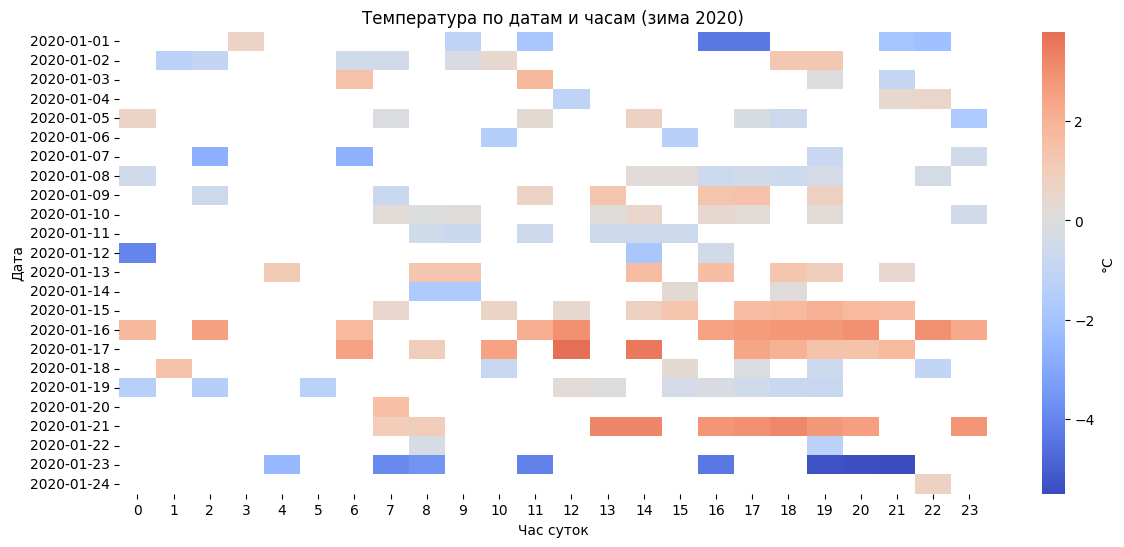

In [ ]:
# Добавим колонки час и дата
df_cell['hour'] = df_cell['time_bucket'].dt.hour
df_cell['date'] = df_cell['time_bucket'].dt.date

# Сводная таблица (дата vs час, значение - температура)
pivot_temp = df_cell.pivot_table(index='date', columns='hour', values='temp_c', aggfunc='mean')

plt.figure(figsize=(14,6))
sns.heatmap(pivot_temp, cmap='coolwarm', center=0, cbar_kws={'label': '°C'})
plt.title('Температура по датам и часам (зима 2020)')
plt.ylabel('Дата')
plt.xlabel('Час суток')
plt.show()

In [ ]:
pivot_temp

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,NaN,NaN,NaN,0.683333,NaN,NaN,NaN,NaN,NaN,-1.200,...,NaN,NaN,-4.40,-4.350000,NaN,NaN,NaN,-1.950000,-2.1,NaN
2020-01-02,NaN,-1.275,-0.975,NaN,NaN,NaN,-0.550,-0.500,NaN,-0.200,...,NaN,NaN,NaN,NaN,1.250,1.200,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,1.450,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000,NaN,-0.900000,NaN,NaN
2020-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.416667,0.6,NaN
2020-01-05,0.65,NaN,NaN,NaN,NaN,NaN,NaN,-0.100,NaN,NaN,...,0.750,NaN,NaN,-0.250000,-0.650,NaN,NaN,NaN,NaN,-1.75
2020-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-1.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,-2.750,NaN,NaN,NaN,-2.700,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.800,NaN,NaN,NaN,-0.55
2020-01-08,-0.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.150,0.15,-0.65,-0.550000,-0.600,-0.350,NaN,NaN,-0.4,NaN
2020-01-09,NaN,NaN,-0.650,NaN,NaN,NaN,NaN,-0.750,NaN,NaN,...,NaN,NaN,1.35,1.450000,NaN,0.850,NaN,NaN,NaN,NaN
